# 05 - Neural Network Classification

Goal: classify songs into Low, Medium, and High popularity categories using PyTorch. The target classes were created with quantile bins to keep the class distribution balanced.

In [1]:
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_RAW = PROJECT_ROOT / "data" / "raw" / "dataset.csv"
DATA_CLEAN = PROJECT_ROOT / "data" / "processed" / "spotify_tracks_clean.csv"

RANDOM_STATE = 42

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder

sns.set_theme(style="whitegrid", palette="Set2")
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

df = pd.read_csv(DATA_CLEAN)
print(df.shape)
display(df["popularity_class"].value_counts().sort_index().to_frame("count"))

(89741, 23)


,count
popularity_class,
High,29870
Low,31659
Medium,28212


## Architecture and Training Choices

The network is a compact feed-forward classifier for tabular data:

- Input layer equals the number of encoded features.
- Hidden layers: 128 neurons then 64 neurons.
- ReLU activations are used because they train efficiently and handle nonlinear feature relationships.
- Dropout and weight decay provide regularization.
- Cross-entropy loss is used because this is a multiclass classification problem.
- Early stopping prevents overfitting by stopping when validation loss stops improving.

In [3]:
numeric_features = [
    "duration_min", "is_explicit", "danceability", "energy", "key", "loudness",
    "mode", "speechiness", "acousticness", "instrumentalness", "liveness",
    "valence", "tempo", "time_signature"
]
categorical_features = ["track_genre"]

X = df[numeric_features + categorical_features]
y = df["popularity_class"].astype(str)

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=RANDOM_STATE, stratify=y_encoded
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=RANDOM_STATE, stratify=y_train
)

try:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features),
        ("genre", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", encoder)
        ]), categorical_features)
    ]
)

X_train_np = preprocessor.fit_transform(X_train).astype(np.float32)
X_val_np = preprocessor.transform(X_val).astype(np.float32)
X_test_np = preprocessor.transform(X_test).astype(np.float32)

print(f"Encoded feature count: {X_train_np.shape[1]}")

Encoded feature count: 127


In [4]:
class PopularityClassifier(nn.Module):
    def __init__(self, input_dim, n_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.20),
            nn.Linear(64, n_classes),
        )

    def forward(self, x):
        return self.net(x)


batch_size = 512
train_loader = DataLoader(
    TensorDataset(torch.tensor(X_train_np), torch.tensor(y_train, dtype=torch.long)),
    batch_size=batch_size,
    shuffle=True,
)
val_tensor = torch.tensor(X_val_np)
test_tensor = torch.tensor(X_test_np)

model = PopularityClassifier(X_train_np.shape[1], len(label_encoder.classes_))
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

best_val_loss = np.inf
best_state = None
patience = 4
patience_counter = 0
history = []
max_epochs = 20

for epoch in range(1, max_epochs + 1):
    model.train()
    train_losses = []
    correct = 0
    total = 0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())
        correct += (logits.argmax(dim=1) == yb).sum().item()
        total += len(yb)

    model.eval()
    with torch.no_grad():
        val_logits = model(val_tensor)
        val_loss = criterion(val_logits, torch.tensor(y_val, dtype=torch.long)).item()
        val_acc = (val_logits.argmax(dim=1).numpy() == y_val).mean()

    train_loss = float(np.mean(train_losses))
    train_acc = correct / total
    history.append({"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss, "train_acc": train_acc, "val_acc": val_acc})

    if val_loss < best_val_loss - 1e-4:
        best_val_loss = val_loss
        best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch}")
        break

if best_state is not None:
    model.load_state_dict(best_state)

history_df = pd.DataFrame(history)
display(history_df.tail())

,epoch,train_loss,val_loss,train_acc,val_acc
15,16,0.698677,0.708380,0.692529,0.681106
16,17,0.696621,0.708729,0.693469,0.679992
17,18,0.695128,0.707829,0.692790,0.679922
18,19,0.694445,0.707296,0.696098,0.680340
19,20,0.693108,0.705938,0.695332,0.683334


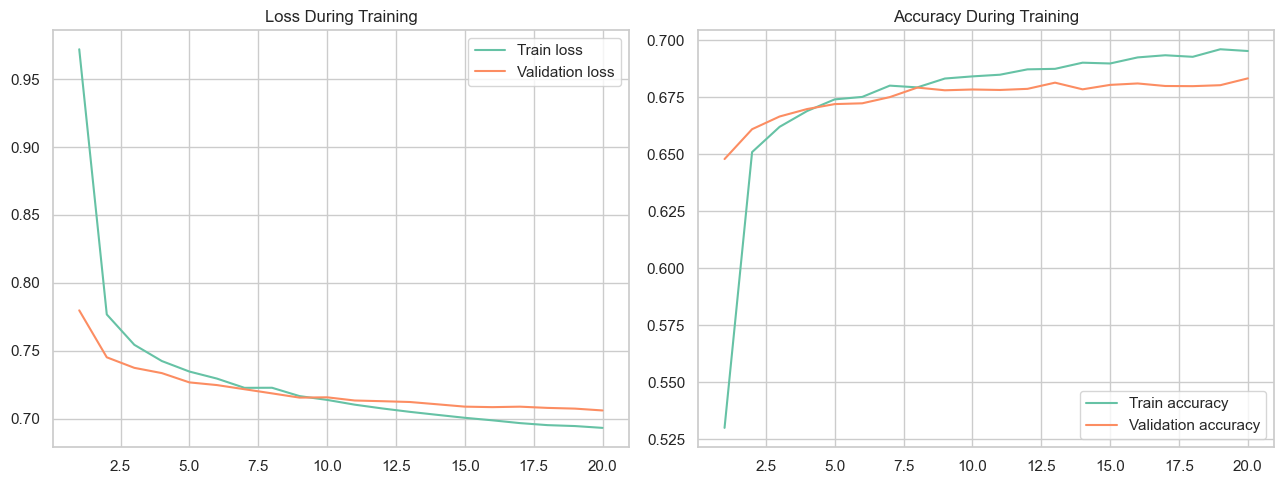

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(history_df["epoch"], history_df["train_loss"], label="Train loss")
axes[0].plot(history_df["epoch"], history_df["val_loss"], label="Validation loss")
axes[0].set_title("Loss During Training")
axes[0].legend()

axes[1].plot(history_df["epoch"], history_df["train_acc"], label="Train accuracy")
axes[1].plot(history_df["epoch"], history_df["val_acc"], label="Validation accuracy")
axes[1].set_title("Accuracy During Training")
axes[1].legend()
plt.tight_layout()
plt.show()

In [6]:
model.eval()
with torch.no_grad():
    train_pred = model(torch.tensor(X_train_np)).argmax(dim=1).numpy()
    test_pred = model(test_tensor).argmax(dim=1).numpy()

def specificity_macro(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    specs = []
    for i in range(cm.shape[0]):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        tn = cm.sum() - tp - fp - fn
        specs.append(tn / (tn + fp) if (tn + fp) else 0)
    return float(np.mean(specs))

precision, recall, f1, _ = precision_recall_fscore_support(
    y_test, test_pred, average="macro", zero_division=0
)

metrics = pd.DataFrame({
    "metric": ["Accuracy", "Precision", "Recall", "Specificity", "F1 Score"],
    "test_value": [
        accuracy_score(y_test, test_pred),
        precision,
        recall,
        specificity_macro(y_test, test_pred),
        f1,
    ],
})

train_accuracy = accuracy_score(y_train, train_pred)
test_accuracy = accuracy_score(y_test, test_pred)

display(metrics.round(4))
print(f"Train accuracy: {train_accuracy:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")

,metric,test_value
0,Accuracy,0.6821
1,Precision,0.6804
2,Recall,0.6776
3,Specificity,0.8405
4,F1 Score,0.6758


Train accuracy: 0.7080
Test accuracy: 0.6821


,High,Low,Medium
High,4267,848,859
Low,771,4917,644
Medium,1342,1242,3059


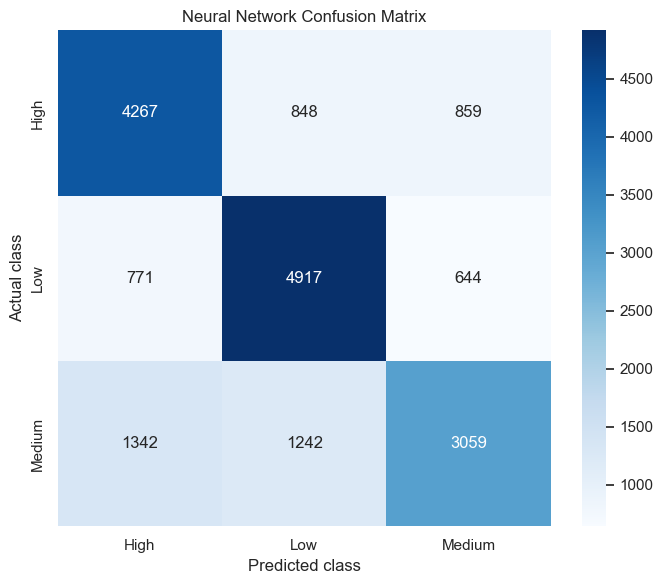

In [7]:
cm = confusion_matrix(y_test, test_pred)
cm_df = pd.DataFrame(cm, index=label_encoder.classes_, columns=label_encoder.classes_)
display(cm_df)

plt.figure(figsize=(7, 6))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title("Neural Network Confusion Matrix")
plt.xlabel("Predicted class")
plt.ylabel("Actual class")
plt.tight_layout()
plt.show()

In [8]:
error_df = X_test.copy()
error_df["actual"] = label_encoder.inverse_transform(y_test)
error_df["predicted"] = label_encoder.inverse_transform(test_pred)
errors = error_df[error_df["actual"] != error_df["predicted"]]

error_pairs = (
    errors.groupby(["actual", "predicted"])
    .size()
    .sort_values(ascending=False)
    .to_frame("count")
)
display(error_pairs.head(10))

genre_errors = (
    errors["track_genre"]
    .value_counts()
    .head(10)
    .to_frame("misclassified_count")
)
display(genre_errors)

print("Interpretation:")
print("- Most classification errors occur near adjacent popularity bands because quantile classes split a continuous score into categories.")
print("- Dropout, feature normalization, weight decay, and early stopping were used to improve generalization.")
print(f"- Train/test accuracy gap: {train_accuracy - test_accuracy:.4f}. A small gap suggests limited overfitting; a large gap would indicate poor generalization.")

count
actual predicted       
Medium High        1342
       Low         1242
High   Medium       859
       Low          848
Low    High         771
       Medium       644

,misclassified_count
track_genre,
disco,114
new-age,104
show-tunes,103
club,103
synth-pop,102
dancehall,100
study,100
bluegrass,100
minimal-techno,100


Interpretation:
- Most classification errors occur near adjacent popularity bands because quantile classes split a continuous score into categories.
- Dropout, feature normalization, weight decay, and early stopping were used to improve generalization.
- Train/test accuracy gap: 0.0259. A small gap suggests limited overfitting; a large gap would indicate poor generalization.
